# 🧑‍💼 HR Analytics: Employee Attrition Analysis

**Author:** diana-data-analyst  
**Tool:** Python (pandas, matplotlib, seaborn)  
**Dataset:** 250 employees, 6 departments, 2024

## 📌 Project Goal
Analyze HR data to understand what factors influence employee attrition.

**Key questions:**
- Which departments have the highest attrition rate?
- Does salary affect employee retention?
- What is the main driver of attrition?

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [27]:
import random

random.seed(42)
np.random.seed(42)

departments = ['Engineering', 'Sales', 'HR', 'Marketing', 'Finance', 'Operations']
positions = {
    'Engineering': ['Junior Developer', 'Senior Developer', 'Tech Lead'],
    'Sales': ['Sales Rep', 'Senior Sales Rep', 'Sales Manager'],
    'HR': ['HR Specialist', 'HR Manager', 'HR Director'],
    'Marketing': ['Marketing Specialist', 'Marketing Manager', 'CMO'],
    'Finance': ['Financial Analyst', 'Senior Analyst', 'CFO'],
    'Operations': ['Operations Specialist', 'Operations Manager', 'COO']
}
cities = ['Kyiv', 'Lviv', 'Odesa', 'Kharkiv', 'Dnipro']

data = []
for i in range(250):
    dept = random.choice(departments)
    position = random.choice(positions[dept])
    age = random.randint(22, 55)
    years = random.randint(0, 15)
    salary = round(np.random.normal(3000, 800), 2)
    salary = max(1000, min(7000, salary))
    satisfaction = random.randint(1, 5)
    performance = random.randint(1, 5)
    attrition = 1 if (satisfaction <= 2 or salary < 1500) and random.random() > 0.4 else 0

    data.append({
        'employee_id': i + 1,
        'department': dept,
        'position': position,
        'age': age,
        'years_at_company': years,
        'salary': salary,
        'city': random.choice(cities),
        'satisfaction_score': satisfaction,
        'performance_score': performance,
        'attrition': attrition
    })

df = pd.DataFrame(data)
df.to_csv('hr_data.csv', index=False)
print(f"Dataset created: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset created: 250 rows, 10 columns


,employee_id,department,position,age,years_at_company,salary,city,satisfaction_score,performance_score,attrition
0,1,Operations,Operations Specialist,23,8,3397.37,Kyiv,2,2,0
1,2,Operations,COO,27,13,2889.39,Lviv,1,1,0
2,3,Finance,CFO,23,6,3518.15,Lviv,5,4,0
3,4,Marketing,CMO,39,0,4218.42,Lviv,2,4,0
4,5,Sales,Senior Sales Rep,28,2,2812.68,Odesa,4,1,0


## 🔍 Data Overview
Basic exploration of the dataset — structure, statistics, and missing values.

In [28]:
print("=== GENERAL INFO ===")
print(df.info())
print("\n=== FIRST 5 ROWS ===")
print(df.head())
print("\n=== STATISTICS ===")
print(df.describe().round(2))
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== GENERAL INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         250 non-null    int64  
 1   department          250 non-null    str    
 2   position            250 non-null    str    
 3   age                 250 non-null    int64  
 4   years_at_company    250 non-null    int64  
 5   salary              250 non-null    float64
 6   city                250 non-null    str    
 7   satisfaction_score  250 non-null    int64  
 8   performance_score   250 non-null    int64  
 9   attrition           250 non-null    int64  
dtypes: float64(1), int64(6), str(3)
memory usage: 19.7 KB
None

=== FIRST 5 ROWS ===
   employee_id  department               position  age  years_at_company  \
0            1  Operations  Operations Specialist   23                 8   
1            2  Operations                    COO   27     

## 📊 1. Employees by Department

C:\Users\diana\AppData\Local\Temp\ipykernel_19948\3108982950.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Blues_d')


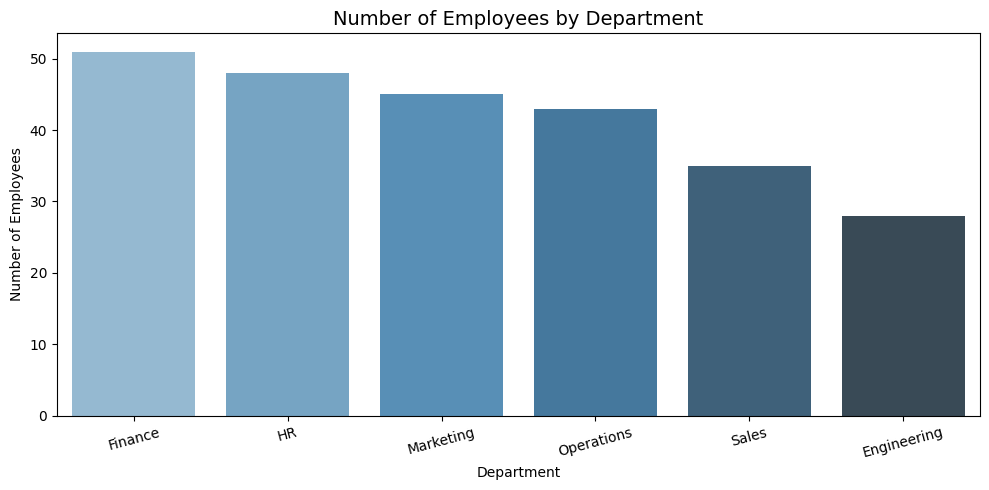

department
Finance        51
HR             48
Marketing      45
Operations     43
Sales          35
Engineering    28
Name: count, dtype: int64


In [29]:
plt.figure(figsize=(10, 5))
dept_counts = df['department'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Blues_d')

plt.title('Number of Employees by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart_1_departments.png', dpi=150)
plt.show()

print(dept_counts)

## 📊 2. Attrition Rate by Department
Engineering has the highest attrition rate (43%), Finance the lowest.

C:\Users\diana\AppData\Local\Temp\ipykernel_19948\4016798885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_dept.index, y=attrition_by_dept.values, palette='Reds_d')


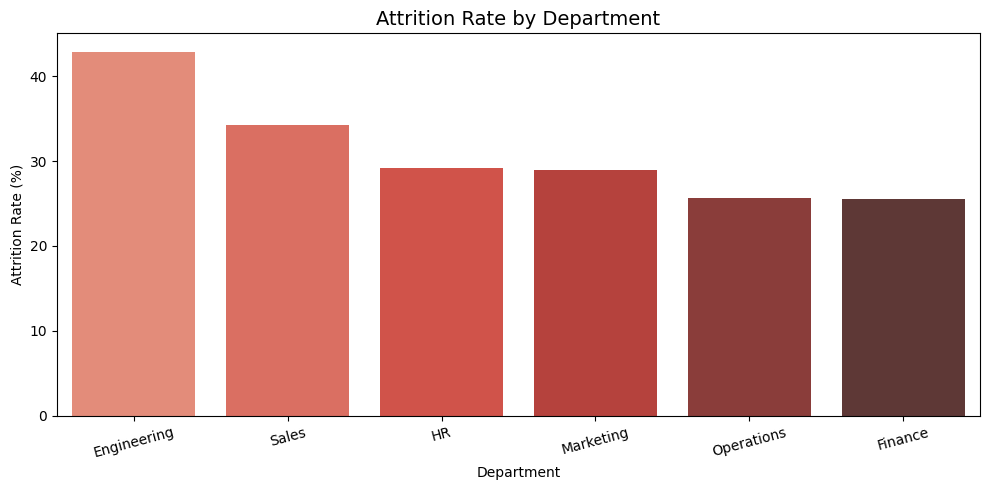

department
Engineering    42.9
Sales          34.3
HR             29.2
Marketing      28.9
Operations     25.6
Finance        25.5
Name: attrition, dtype: float64


In [30]:
attrition_by_dept = df.groupby('department')['attrition'].mean().round(3) * 100
attrition_by_dept = attrition_by_dept.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=attrition_by_dept.index, y=attrition_by_dept.values, palette='Reds_d')

plt.title('Attrition Rate by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart_2_attrition_by_dept.png', dpi=150)
plt.show()

print(attrition_by_dept)

## 📊 3. Salary Distribution
Most employees earn around $3,000. Distribution follows a normal curve.

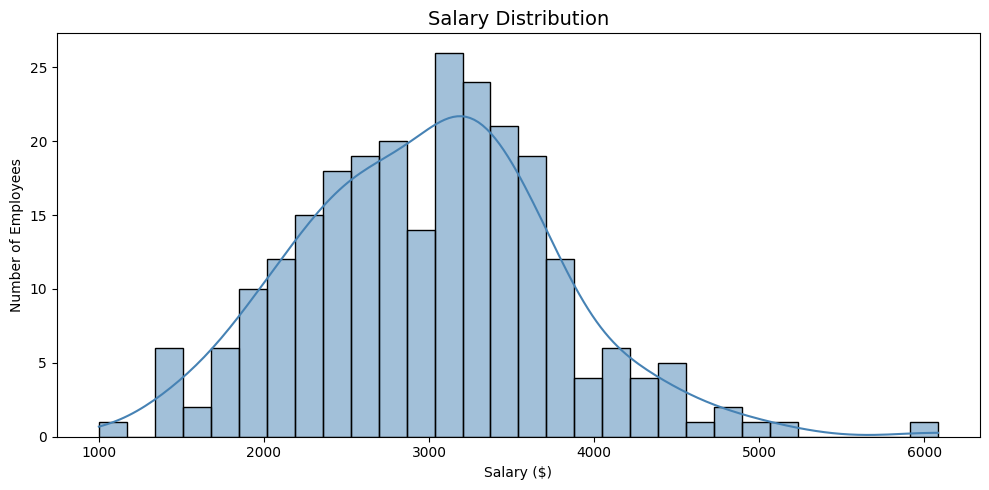

Mean salary: $2998.44
Median salary: $3047.38
Min: $1000.00 | Max: $6082.19


In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(df['salary'], bins=30, color='steelblue', kde=True)

plt.title('Salary Distribution', fontsize=14)
plt.xlabel('Salary ($)')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('chart_3_salary_distribution.png', dpi=150)
plt.show()

print(f"Mean salary: ${df['salary'].mean():.2f}")
print(f"Median salary: ${df['salary'].median():.2f}")
print(f"Min: ${df['salary'].min():.2f} | Max: ${df['salary'].max():.2f}")

## 📊 4. Average Salary by Department
Engineering leads with ~$3,220, Marketing pays the least (~$2,870).

C:\Users\diana\AppData\Local\Temp\ipykernel_19948\3720508350.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary.index, y=avg_salary.values, palette='Greens_d')


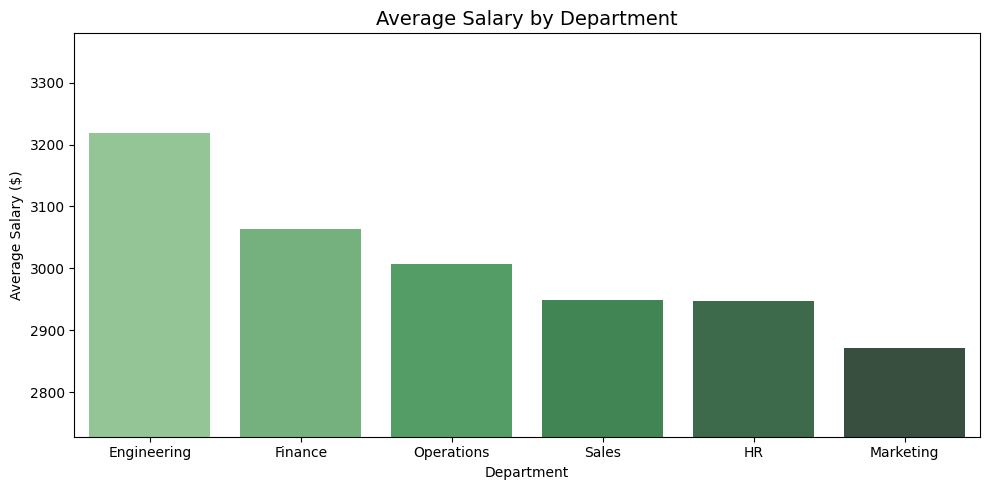

department
Engineering    3218.53
Finance        3063.85
Operations     3006.41
Sales          2949.23
HR             2947.98
Marketing      2871.88
Name: salary, dtype: float64


In [32]:
avg_salary = df.groupby('department')['salary'].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_salary.index, y=avg_salary.values, palette='Greens_d')

plt.title('Average Salary by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Average Salary ($)')
plt.ylim(avg_salary.min() * 0.95, avg_salary.max() * 1.05)
plt.tight_layout()
plt.savefig('chart_4_avg_salary_by_dept.png', dpi=150)
plt.show()

print(avg_salary)

## 📊 5. Attrition by Satisfaction Score
⚠️ Key finding: employees with satisfaction score 1 leave in 71% of cases!

C:\Users\diana\AppData\Local\Temp\ipykernel_19948\532027198.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_by_satisfaction.index, y=attrition_by_satisfaction.values, palette='Oranges_d')


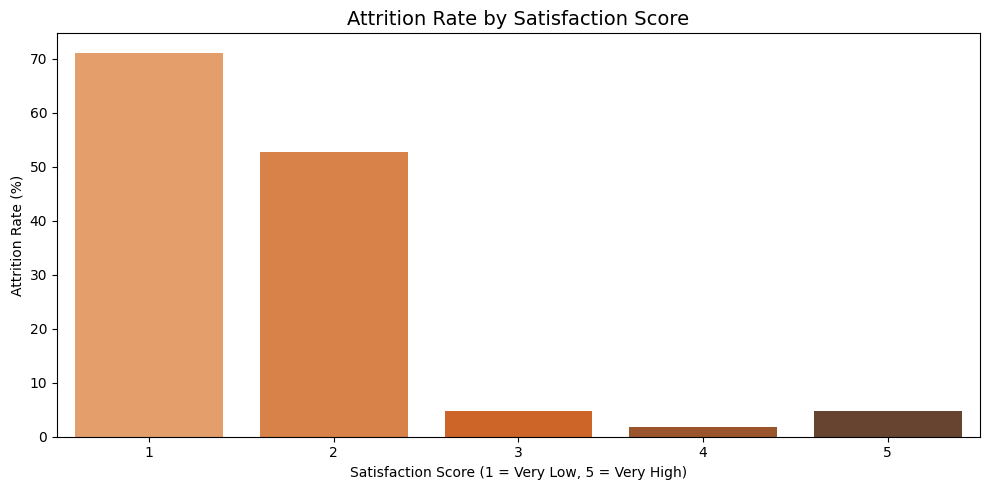

satisfaction_score
1    71.2
2    52.8
3     4.8
4     1.9
5     4.8
Name: attrition, dtype: float64


In [33]:
attrition_by_satisfaction = df.groupby('satisfaction_score')['attrition'].mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=attrition_by_satisfaction.index, y=attrition_by_satisfaction.values, palette='Oranges_d')

plt.title('Attrition Rate by Satisfaction Score', fontsize=14)
plt.xlabel('Satisfaction Score (1 = Very Low, 5 = Very High)')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('chart_5_attrition_by_satisfaction.png', dpi=150)
plt.show()

print(attrition_by_satisfaction.round(1))

## 📊 6. Salary: Stayed vs Left
In HR and Marketing, employees who left earned significantly less.

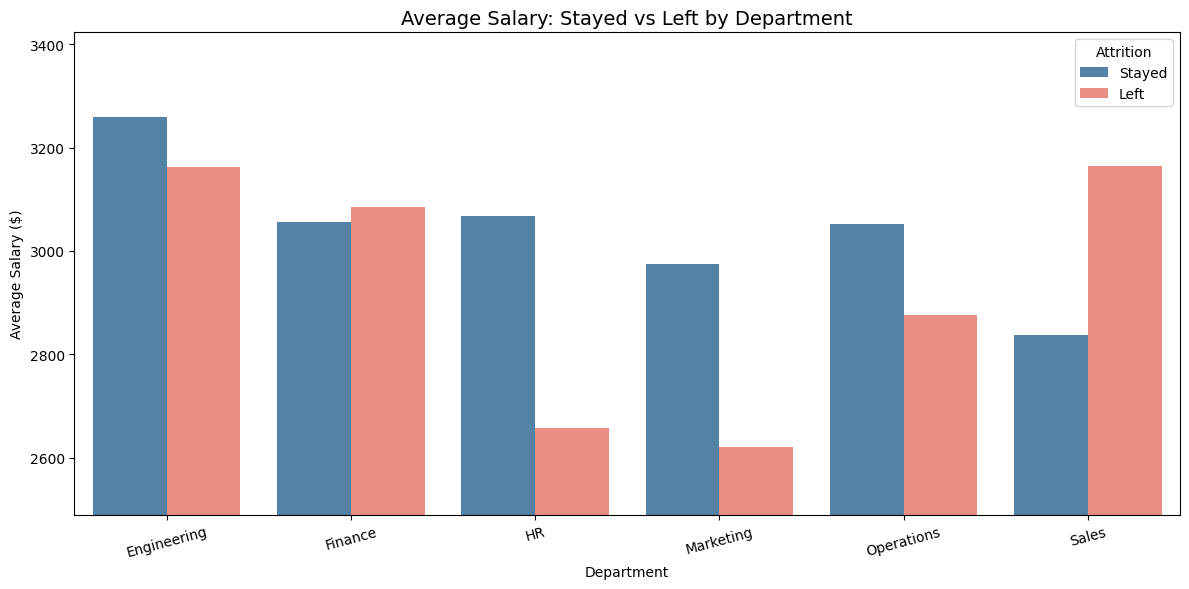

In [34]:
salary_attrition = df.groupby(['department', 'attrition'])['salary'].mean().round(2).reset_index()
salary_attrition['attrition'] = salary_attrition['attrition'].map({0: 'Stayed', 1: 'Left'})

plt.figure(figsize=(12, 6))
sns.barplot(data=salary_attrition, x='department', y='salary', 
            hue='attrition', palette={'Stayed': 'steelblue', 'Left': 'salmon'})

plt.title('Average Salary: Stayed vs Left by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=15)
plt.legend(title='Attrition')
plt.ylim(salary_attrition['salary'].min() * 0.95, salary_attrition['salary'].max() * 1.05)
plt.tight_layout()
plt.savefig('chart_6_salary_stayed_vs_left.png', dpi=150)
plt.show()

## 📊 7. Correlation Heatmap
Satisfaction score has the strongest correlation with attrition (-0.6).

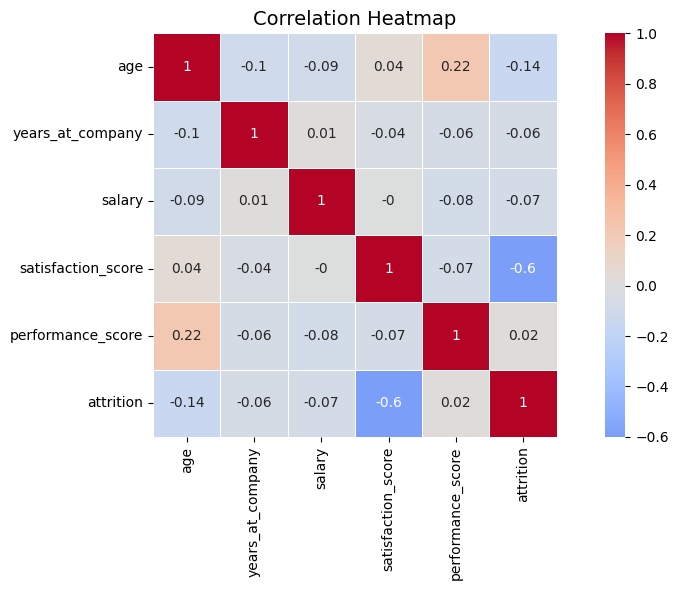

In [35]:
plt.figure(figsize=(10, 6))
corr = df[['age', 'years_at_company', 'salary', 'satisfaction_score', 
           'performance_score', 'attrition']].corr().round(2)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('chart_7_correlation_heatmap.png', dpi=150)
plt.show()

## 📊 8. Attrition Overview
30% of employees left the company.

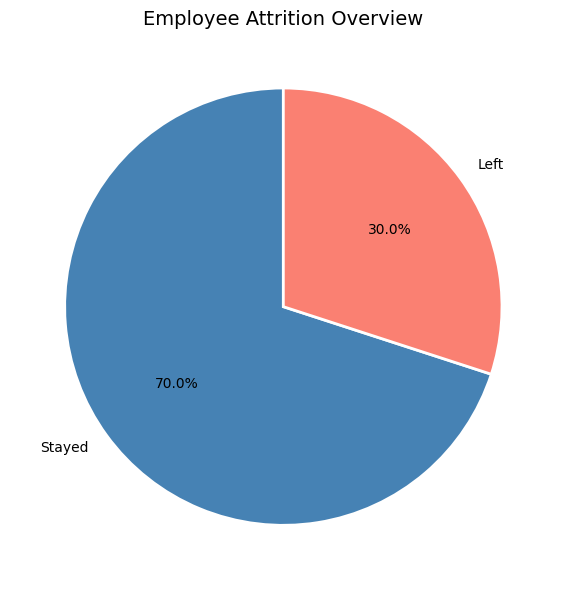

Stayed: 175 employees
Left: 75 employees


In [36]:
attrition_counts = df['attrition'].value_counts()
labels = ['Stayed', 'Left']
colors = ['steelblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(attrition_counts.values, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Employee Attrition Overview', fontsize=14)
plt.tight_layout()
plt.savefig('chart_8_attrition_pie.png', dpi=150)
plt.show()

print(f"Stayed: {attrition_counts[0]} employees")
print(f"Left: {attrition_counts[1]} employees")

## 📊 9. Average Salary by Position
HR Director and Senior Developer are the highest paid positions.

C:\Users\diana\AppData\Local\Temp\ipykernel_19948\3302017522.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_position.values, y=avg_salary_position.index, palette='Blues_d')


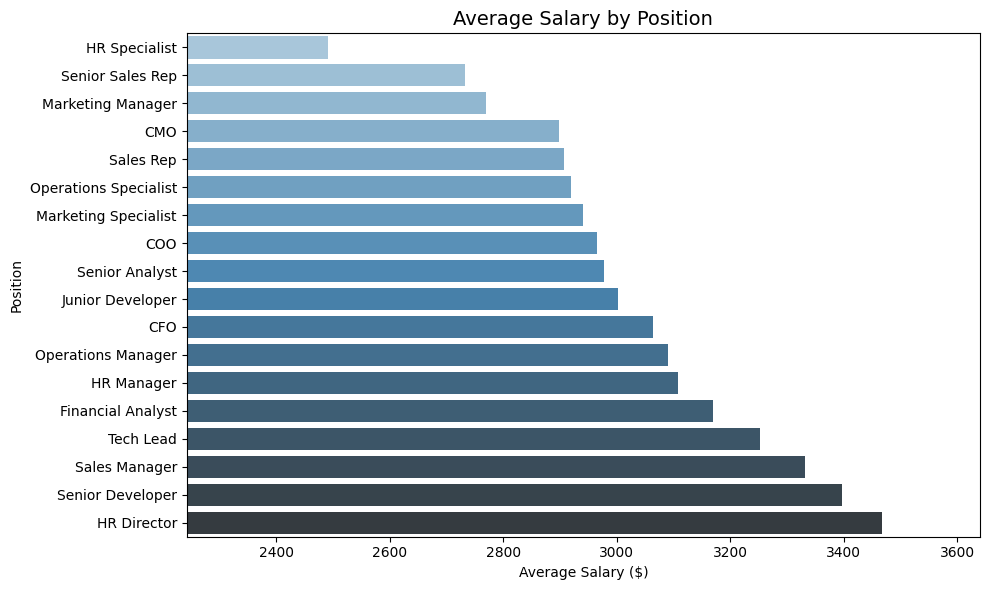

In [37]:
avg_salary_position = df.groupby('position')['salary'].mean().round(2).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_salary_position.values, y=avg_salary_position.index, palette='Blues_d')

plt.title('Average Salary by Position', fontsize=14)
plt.xlabel('Average Salary ($)')
plt.ylabel('Position')
plt.xlim(avg_salary_position.min() * 0.9, avg_salary_position.max() * 1.05)
plt.tight_layout()
plt.savefig('chart_9_salary_by_position.png', dpi=150)
plt.show()

## 📌 Key Findings

| Metric | Value |
|--------|-------|
| Total Employees | 250 |
| Attrition Rate | 30% |
| Highest Attrition Dept | Engineering (43%) |
| Lowest Attrition Dept | Finance (26%) |
| Main Attrition Driver | Satisfaction Score |
| Avg Salary | ~$3,000 |
| Best Paid Position | HR Director |

## 💡 Conclusions
- **Satisfaction score** is the strongest predictor of attrition (correlation -0.6)
- Employees with satisfaction score 1 leave in **71% of cases**
- **Engineering** has the highest attrition despite competitive salaries
- **Salary alone** does not predict attrition (correlation only -0.07)
- Improving employee satisfaction could reduce attrition significantly